GLOBAL IMPORTS AND CONFIGS

In [12]:
import os

import os
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import (

    KMeans,
    AgglomerativeClustering
)

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
ARRAY_PATH = "processed_arrays/"
MODEL_PATH = "models/"
IMAGE_PATH = "images/"
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(IMAGE_PATH, exist_ok=True)

LOADING THE PREPROCESSED FULL DATA

In [13]:
X_full = np.load(

    os.path.join(
        ARRAY_PATH,
        "X_full.npy"
    ),
    allow_pickle=True
)

y_full = np.load(

    os.path.join(
        ARRAY_PATH,
        "y_full.npy"
    ),
    allow_pickle=True
)

feature_names = np.load(

    os.path.join(
        ARRAY_PATH,
        "feature_names.npy"
    ),
    allow_pickle=True
)

print("Dataset Shape:")
print(X_full.shape)

Dataset Shape:
(1000, 19)


VISUALIZING THE DATA WITH PCA

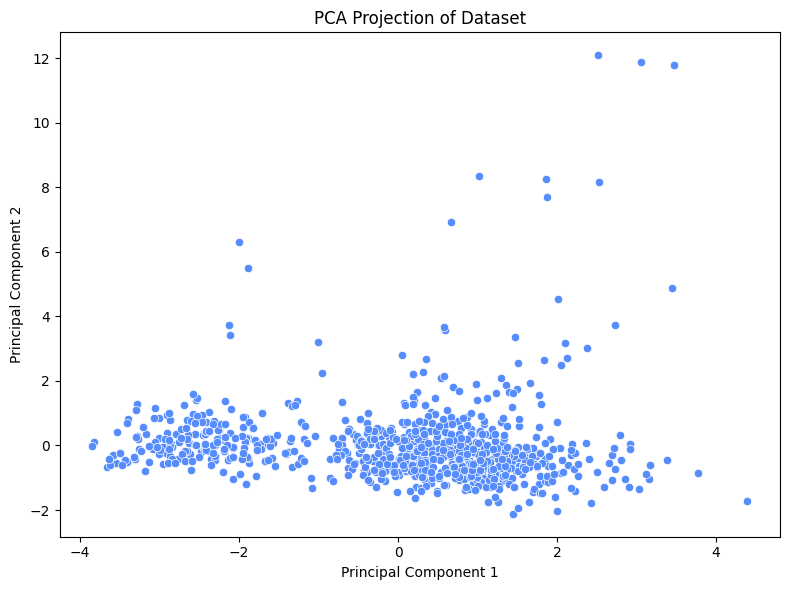

In [14]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_full
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1]
)

plt.title("PCA Projection of Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# CLUSTERING MODELS

### K MEANS ELBOW CLUSTERING METHOD

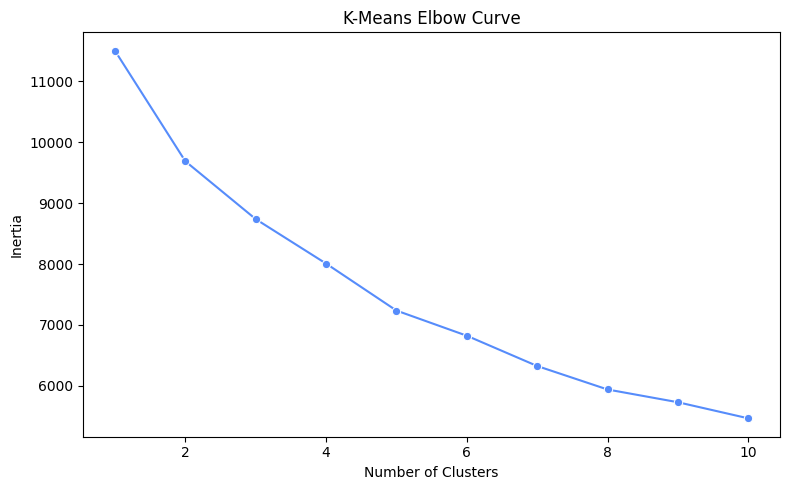

In [15]:
inertia_values = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_temp.fit(X_full)
    inertia_values.append(
        kmeans_temp.inertia_
    )

plt.figure(figsize=(8, 5))

sns.lineplot(
    x=list(cluster_range),
    y=inertia_values,
    marker="o"
)

plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "kmeans_elbow_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(
    X_full
)

print("K-Means Training Complete")

joblib.dump(
    kmeans_model,
    os.path.join(
        MODEL_PATH,
        "kmeans_model.joblib"
    )
)

K-Means Training Complete


['models/kmeans_model.joblib']

CLUSTER VISUALIZATION

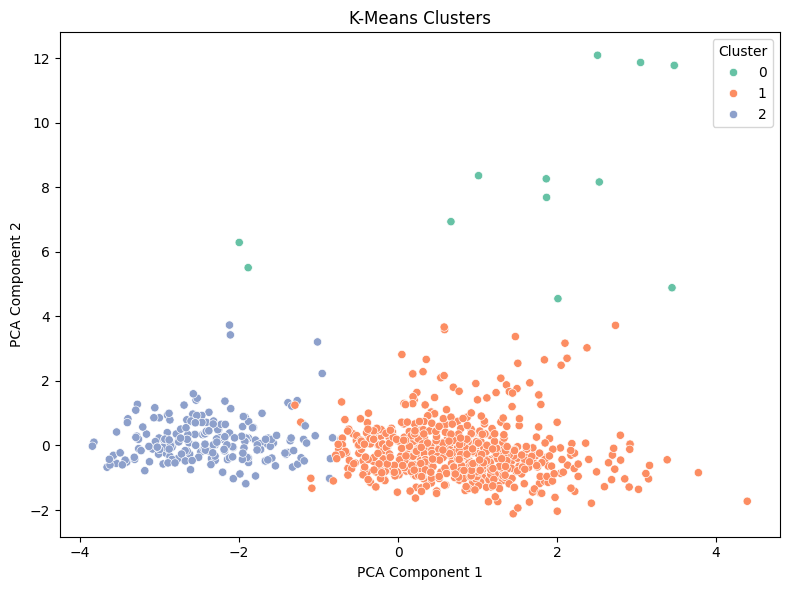

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set2"
)

plt.title("K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "kmeans_clusters.png"
    ),

    dpi=300,
    bbox_inches="tight"
)

plt.show()

### HIERARCHICAL CLUSTERING METHOD

In [18]:
hierarchical_model = AgglomerativeClustering(

    n_clusters=3,

    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_full
)

np.save(

    os.path.join(
        MODEL_PATH,
        "hierarchical_labels.npy"
    ),

    hierarchical_labels
)

VISUALIZING HIERARCHICAL CLUSTERS

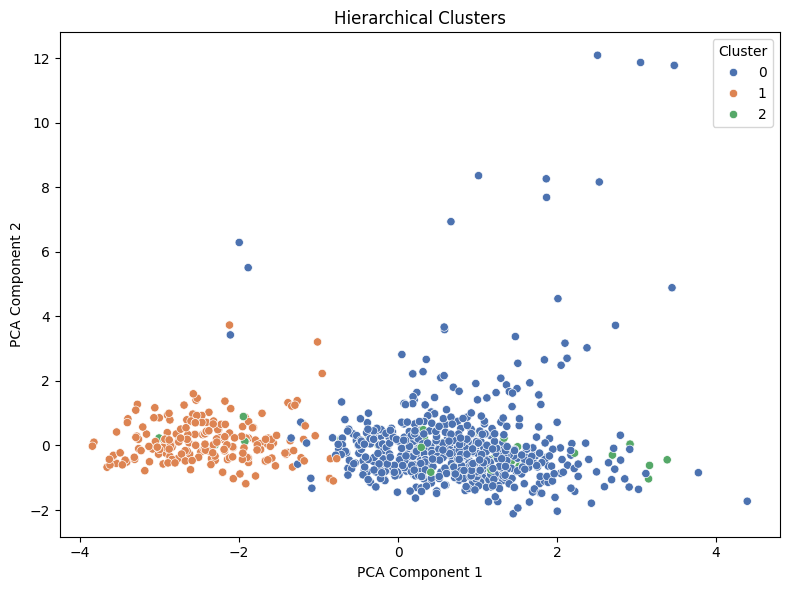

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(

    x=X_pca[:, 0],

    y=X_pca[:, 1],

    hue=hierarchical_labels,

    palette="deep"
)

plt.title("Hierarchical Clusters")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "hierarchical_clusters.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

### GAUSSIAN MIXTURE METHOD

In [20]:
gmm_model = GaussianMixture(
    n_components=3,       # N / P / Y classes
    covariance_type="full",
    random_state=42,
    n_init=10             # run 10 times, keep best
)

gmm_labels = gmm_model.fit_predict(
    X_full
)

np.save(
    os.path.join(
        MODEL_PATH,
        "gmm_labels.npy"
    ),
    gmm_labels
)

unique_clusters = np.unique(
    gmm_labels
)

print("Unique GMM Clusters:")
print(unique_clusters)

Unique GMM Clusters:
[0 1 2]


VISUALIZING DBSCAN CLUSTERS

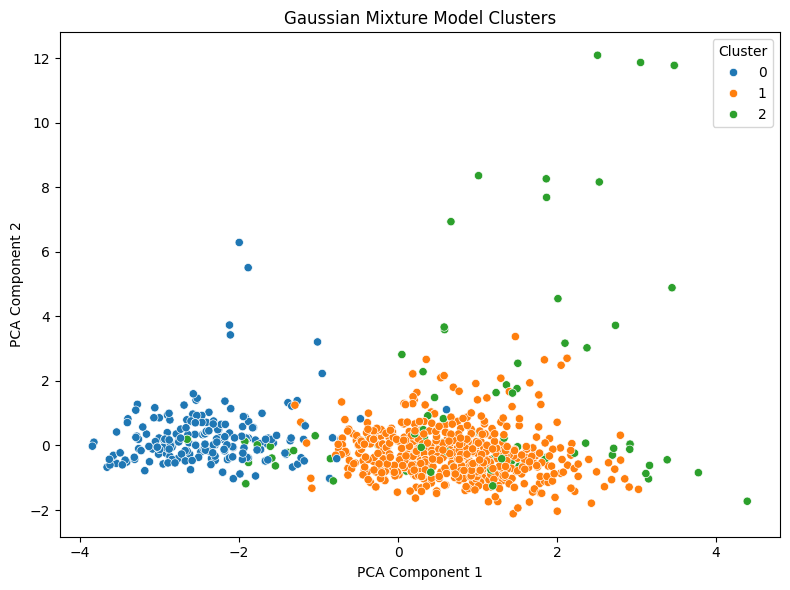

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=gmm_labels,
    palette="tab10"
)

plt.title("Gaussian Mixture Model Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "gmm_clusters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()